# Assignment 3: The "Multimodal Sentiment Engine" Challenge

**Total Marks:** 20 | **Deadline:** 7:00 PM, 22nd March, 2026 | 
**Submission:** A zip file of the folder containing this notebook, and the csv/image files you will create.


---

## Setup

Run the cell below **once** to install all required packages and download NLTK data.

In [76]:
!pip install -r requirements.txt -q

import nltk
for pkg in ["wordnet", "averaged_perceptron_tagger_eng", "punkt_tab", "omw-1.4"]:
    nltk.download(pkg, quiet=True)
print("Setup complete!")

Setup complete!


In [ ]:
import os, re, json, time, random, warnings
from collections import Counter
from itertools import combinations
from deep_translator import GoogleTranslator
import time

from dotenv import load_dotenv
load_dotenv()

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag

warnings.filterwarnings("ignore")

# OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "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")
OPENROUTER_API_KEY = "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"
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
LLM_MODEL = "google/gemini-2.0-flash-001"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Sentiment-bearing words to preserve during augmentation
PRESERVE_WORDS = {
    "amazing", "terrible", "awful", "excellent", "wonderful", "horrible",
    "great", "bad", "good", "worst", "best", "love", "hate", "boring",
    "fantastic", "brilliant", "pathetic", "outstanding", "dreadful",
    "superb", "mediocre",
}
print("Imports loaded. API key present:", bool(OPENROUTER_API_KEY))
# print(OPENROUTER_API_KEY)

Imports loaded. API key present: True
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


## Task 1: Data Consolidation & Classical Augmentation (5 Marks)

**Steps:**
1. Load all three CSVs and merge them
2. Train a baseline Logistic Regression on `gold_standard_100.csv` (TF-IDF features)
3. Filter `llm_labels_150.csv` -- keep only reviews where baseline confidence ≥ 0.65 AND agrees with LLM label
4. Deduplicate by review text $\rightarrow$ save `consolidated_base.csv`
5. Identify minority class, apply 2 augmentation methods (Synonym Replacement, Back Translation)
6. Quality filter augmented samples (Jaccard similarity)
7. Save `augmented_classical.csv` and `class_distribution.png`

Gold: 100, Weak: 220, LLM: 150
Filtered LLM labels: 27 out of 150 retained.
Consolidated base dataset size: 328
Class Distribution:
label
Negative    151
Neutral     115
Positive     62
Name: count, dtype: int64
Identified Minority Class: **Positive**


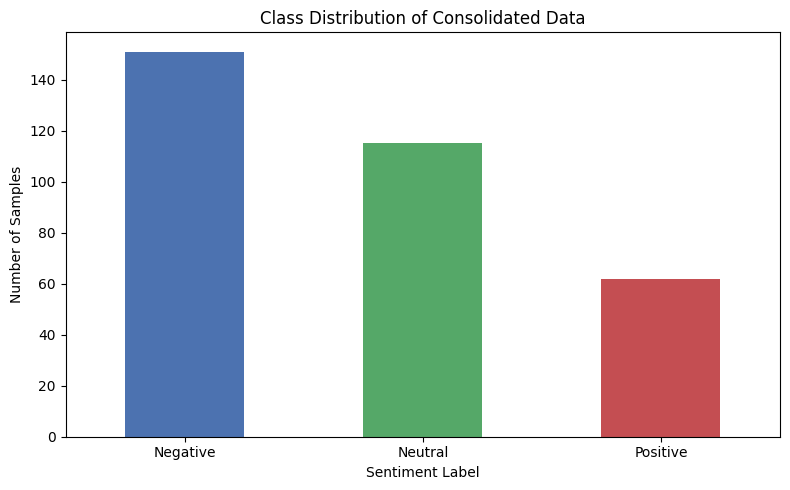

In [29]:
gold = pd.read_csv("gold_standard_100.csv")
weak = pd.read_csv("weak_labels_200.csv")
llm  = pd.read_csv("llm_labels_150.csv")
print(f"Gold: {len(gold)}, Weak: {len(weak)}, LLM: {len(llm)}")

def train_baseline_model(train_df, text_col="review", label_col="label"):
    """Returns (vectorizer, classifier) trained on the given dataframe."""
    vec = TfidfVectorizer(max_features=5000, stop_words="english")
    X = vec.fit_transform(train_df[text_col])
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(X, train_df[label_col])
    return vec, clf

vec, clf = train_baseline_model(gold)

# 1c. Filter LLM labels by confidence 
# Predict on llm reviews, keep where confidence >= 0.65 AND prediction matches LLM label
X_llm = vec.transform(llm["review"])
llm_preds = clf.predict(X_llm)
# Get maximum probability for each prediction as the confidence score
llm_probs = clf.predict_proba(X_llm).max(axis=1) 
valid_llm_mask = (llm_probs >= 0.65) & (llm_preds == llm["label"])
filtered_llm = llm[valid_llm_mask].copy()
print(f"Filtered LLM labels: {len(filtered_llm)} out of {len(llm)} retained.")

# 1d. Merge & deduplicate  
# Combine gold + weak + filtered_llm, drop_duplicates on "review"
consolidated_base = pd.concat([gold, weak, filtered_llm], ignore_index=True)
consolidated_base = consolidated_base.drop_duplicates(subset=["review"])

# Save as consolidated_base.csv
consolidated_base.to_csv("consolidated_base.csv", index=False)
print(f"Consolidated base dataset size: {len(consolidated_base)}")

# 1e. Class distribution analysis 
# Count per class, identify minority, plot and save class_distribution.png
class_counts = consolidated_base["label"].value_counts()
minority_class = class_counts.idxmin()

print(f"Class Distribution:\n{class_counts}")
print(f"Identified Minority Class: **{minority_class}**")

# Plotting the graphs
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Class Distribution of Consolidated Data")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

In [52]:
# 1f. Augmentation functions
def get_wordnet_pos(treebank_tag):
    """Map NLTK POS tags to WordNet POS tags for accurate synonym retrieval."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

def synonym_replacement(text, replace_frac=0.15):
    """Replace 15-20% of words with WordNet synonyms. Preserve sentiment-bearing words."""
    words = word_tokenize(text)
    tagged_words = pos_tag(words)
    
    # Identify indices of words we are allowed to replace
    eligible_indices = [
        i for i, (word, tag) in enumerate(tagged_words)
        if word.lower() not in PRESERVE_WORDS and word.isalnum()
    ]
    
    # Calculate how many words to replace
    num_replace = max(1, int(len(words) * replace_frac))
    if not eligible_indices:
        return text # Return original if no words can be replaced
        
    replace_indices = random.sample(eligible_indices, min(num_replace, len(eligible_indices)))
    new_words = words.copy()
    
    for idx in replace_indices:
        word, tag = tagged_words[idx]
        wn_pos = get_wordnet_pos(tag)
        
        synonyms = set()
        for syn in wordnet.synsets(word, pos=wn_pos):
            for lemma in syn.lemmas():
                syn_word = lemma.name().replace('_', ' ')
                if syn_word.lower() != word.lower():
                    synonyms.add(syn_word)
                    
        if synonyms:
            new_words[idx] = random.choice(list(synonyms))
            
    return " ".join(new_words)

def back_translate(text, src="en", mid="hi"):
    """Translate English -> Hindi -> English using deep-translator GoogleTranslator."""
    try:
        # Forward translation
        to_hi = GoogleTranslator(source=src, target=mid).translate(text)
        time.sleep(0.5) # Rate limit sleep
        
        # Back translation
        back_to_en = GoogleTranslator(source=mid, target=src).translate(to_hi)
        time.sleep(0.5) # Rate limit sleep
        
        return back_to_en
    except Exception as e:
        print(f"Translation error: {e}")
        return text

def quality_filter(original, augmented):
    """Return True if augmented text passes Jaccard similarity (0.30–0.95)."""
    set_orig = set(word_tokenize(original.lower()))
    set_aug = set(word_tokenize(augmented.lower()))
    
    intersection = len(set_orig.intersection(set_aug))
    union = len(set_orig.union(set_aug))
    
    if union == 0: 
        return False
        
    jaccard = intersection / union
    return 0.30 <= jaccard <= 0.95

# 1g. Apply augmentation to minority class

print("Starting classical augmentation...")
minority_df = consolidated_base[consolidated_base["label"] == minority_class]
augmented_data = []

for _, row in minority_df.iterrows():
    orig_review = row["review"]
    label = row["label"]
    
    # Method A: Synonym Replacement
    aug_syn = synonym_replacement(orig_review)
    if quality_filter(orig_review, aug_syn):
        augmented_data.append({"review": aug_syn, "label": label, "source": "synonym_replacement"})
        
    # Method B: Back Translation
    aug_bt = back_translate(orig_review)
    if quality_filter(orig_review, aug_bt):
        augmented_data.append({"review": aug_bt, "label": label, "source": "back_translation"})

augmented_classical = pd.DataFrame(augmented_data)
augmented_classical.to_csv("augmented_classical.csv", index=False)

print(f"Successfully generated {len(augmented_classical)} valid augmented samples for the '{minority_class}' class.")

Starting classical augmentation...
Successfully generated 118 valid augmented samples for the 'Positive' class.


## Task 2: LLM-Based Synthetic Review Generation (5 Marks)

**Steps:**
1. Design a few-shot prompt with 3-4 gold-standard examples
2. Use OpenRouter API (via `openai` package) to generate 300 synthetic reviews in batches of 20
3. Calculate diversity metrics: Self-BLEU per class
4. Run sentiment consistency check with baseline model $\rightarrow$ flag mismatches
5. Save `llm_generated_300.csv`, `llm_generated_flagged.csv`, `prompt_template.txt`, `diversity_report.txt`

In [81]:
import json
import time
import re
import numpy as np
import pandas as pd
from openai import OpenAI
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize

client = OpenAI(base_url=OPENROUTER_BASE_URL, api_key=OPENROUTER_API_KEY)

# --- 2a. Design your few-shot prompt ---
# We use placeholders for target_sentiment and batch_size to dynamically generate batches.
PROMPT_TEMPLATE = """You are an expert data annotator and movie review generator.
Your task is to generate {batch_size} highly diverse, realistic movie reviews with a strictly '{target_sentiment}' sentiment.

Here are examples of the quality and style we expect:
- "An absolute masterpiece. The acting was phenomenal and the plot twists were genuinely unexpected." (Sentiment: positive)
- "The pacing was incredibly slow, but the stunning cinematography kept me watching until the end." (Sentiment: neutral)
- "Terrible script and wooden acting. A complete waste of time and money." (Sentiment: negative)
- "I really wanted to love this, but the character development felt rushed and the climax fell flat." (Sentiment: negative)

REQUIREMENTS:
1. Ensure high linguistic diversity (vary sentence structures, vocabulary, and lengths).
2. Do NOT use the exact phrasing from the examples above.
3. Output strictly a JSON array of dictionaries with no surrounding text, no markdown blocks, and no explanations.

Expected JSON schema:
[
  {{"review": "...", "sentiment": "{target_sentiment}", "movie": "..."}}
]
"""

# Save prompt to file
with open("prompt_template.txt", "w", encoding="utf-8") as f:
    f.write(PROMPT_TEMPLATE)


def extract_json_array(text):
    """Helper to robustly extract a JSON array from LLM output, ignoring markdown."""
    match = re.search(r'\[.*\]', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass
    return []

# --- 2b. Generate reviews in batches ---
print("Starting LLM generation...")
TARGET_DISTRIBUTION = {"positive": 150, "negative": 100, "neutral": 50}
generated_data = [] 

for sentiment, target_count in TARGET_DISTRIBUTION.items():
    current_count = 0
    print(f"\nGenerating {target_count} {sentiment} reviews...")
    
    while current_count < target_count:
        batch_size = min(20, target_count - current_count)
        prompt = PROMPT_TEMPLATE.format(batch_size=batch_size, target_sentiment=sentiment)
        
        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.8, # Slightly higher temperature for diversity
            )
            
            raw_text = response.choices[0].message.content
            batch_data = extract_json_array(raw_text)
            
            if not batch_data:
                print("Failed to parse JSON, retrying batch...")
                time.sleep(2)
                continue
                
            # Filter out any that didn't follow the sentiment instruction
            valid_batch = [item for item in batch_data if item.get("sentiment", "").lower() == sentiment]
            generated_data.extend(valid_batch)
            current_count += len(valid_batch)
            print(f"  Generated {current_count}/{target_count} {sentiment} reviews.")
            
            time.sleep(1.5) # Rate limit protection
            
        except Exception as e:
            print(f"API Error: {e}. Retrying in 5 seconds...")
            time.sleep(5)

# Convert to DataFrame
df_generated = pd.DataFrame(generated_data)
# Ensure consistent label naming (matching Task 1)
df_generated.rename(columns={"sentiment": "label"}, inplace=True)


# --- 2c. Diversity metrics (Self-BLEU) ---
print("\nCalculating Self-BLEU diversity scores...")
smoother = SmoothingFunction().method1
diversity_results = {}

for label in df_generated["label"].unique():
    class_reviews = df_generated[df_generated["label"] == label]["review"].tolist()
    tokenized_reviews = [word_tokenize(text.lower()) for text in class_reviews]
    
    bleu_scores = []
    # Compare each sentence against all other sentences in the same class
    for i, tokens in enumerate(tokenized_reviews):
        references = tokenized_reviews[:i] + tokenized_reviews[i+1:]
        # Calculate BLEU (lower is more diverse)
        score = sentence_bleu(references, tokens, smoothing_function=smoother)
        bleu_scores.append(score)
    
    avg_bleu = np.mean(bleu_scores)
    diversity_results[label] = avg_bleu
    print(f"  {label.capitalize()} Self-BLEU: {avg_bleu:.4f} (Lower = more diverse)")

# Save diversity report
with open("diversity_report.txt", "w", encoding="utf-8") as f:
    f.write("Self-BLEU Diversity Report (Lower scores indicate higher diversity)\n")
    f.write("="*65 + "\n")
    for label, score in diversity_results.items():
        f.write(f"Class: {label.capitalize():<10} | Average Self-BLEU: {score:.4f}\n")


# --- 2d. Sentiment consistency check ---
print("\nRunning consistency check against Task 1 baseline model...")
# Transform texts using the vectorizer from Task 1
X_gen = vec.transform(df_generated["review"])
    
# Predict using the classifier from Task 1
baseline_preds = clf.predict(X_gen)
df_generated["baseline_pred"] = baseline_preds

# Ensure label capitalization matches baseline for accurate comparison
df_generated["label"] = df_generated["label"].str.capitalize()

# Flag mismatches (where LLM generation intent != Baseline prediction)
df_generated["is_mismatch"] = df_generated["label"] != df_generated["baseline_pred"]
df_flagged = df_generated[df_generated["is_mismatch"]].copy()

print(f"Found {len(df_flagged)} mismatched reviews out of {len(df_generated)}.")

# Remove flagged data from the clean generated set
df_clean_generated = df_generated[~df_generated["is_mismatch"]].drop(columns=["baseline_pred", "is_mismatch"])


# --- 2e. Save outputs ---
df_clean_generated.to_csv("llm_generated_300.csv", index=False)
df_flagged.to_csv("llm_generated_flagged.csv", index=False)

print("Task 2 complete. Files saved: 'llm_generated_300.csv', 'llm_generated_flagged.csv', 'prompt_template.txt', 'diversity_report.txt'.")

Starting LLM generation...

Generating 150 positive reviews...
  Generated 20/150 positive reviews.
  Generated 40/150 positive reviews.
  Generated 60/150 positive reviews.
  Generated 80/150 positive reviews.
  Generated 100/150 positive reviews.
  Generated 120/150 positive reviews.
  Generated 140/150 positive reviews.
  Generated 150/150 positive reviews.

Generating 100 negative reviews...
  Generated 20/100 negative reviews.
  Generated 40/100 negative reviews.
  Generated 60/100 negative reviews.
  Generated 80/100 negative reviews.
  Generated 100/100 negative reviews.

Generating 50 neutral reviews...
  Generated 20/50 neutral reviews.
  Generated 40/50 neutral reviews.
  Generated 50/50 neutral reviews.

Calculating Self-BLEU diversity scores...
  Positive Self-BLEU: 0.4987 (Lower = more diverse)
  Negative Self-BLEU: 0.4213 (Lower = more diverse)
  Neutral Self-BLEU: 0.2411 (Lower = more diverse)

Running consistency check against Task 1 baseline model...
Found 137 mismatch

## Task 3: Multilingual Sentiment Translation (4 Marks)

**Steps:**
1. Sample 100 reviews (40 Pos, 40 Neg, 20 Neu), prioritize shorter reviews
2. Translate English $\rightarrow$ Hindi using `deep-translator` (`GoogleTranslator`)
3. Back-translate Hindi $\rightarrow$ English, compute BLEU score (threshold ≥ 0.3)
4. Check sentiment preservation on back-translated text
5. Manually verify 5 random samples
6. Save `bilingual_reviews.csv` with `bleu_score` and `quality_flag` columns

In [82]:
import time
import pandas as pd
from deep_translator import GoogleTranslator
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize

# --- 3a. Strategic sampling ---
print("Sampling shortest reviews for translation...")
# Calculate word count for each review
consolidated_base["word_count"] = consolidated_base["review"].apply(lambda x: len(str(x).split()))

def get_shortest_samples(df, label, n):
    """Helper to filter by label and grab the shortest 'n' reviews."""
    mask = df["label"].str.lower() == label.lower()
    return df[mask].sort_values("word_count").head(n)

# Sample the exact distribution requested
pos_samples = get_shortest_samples(consolidated_base, "positive", 40)
neg_samples = get_shortest_samples(consolidated_base, "negative", 40)
neu_samples = get_shortest_samples(consolidated_base, "neutral", 20)

df_sample = pd.concat([pos_samples, neg_samples, neu_samples]).copy()
df_sample.drop(columns=["word_count"], inplace=True)
print(f"Successfully sampled {len(df_sample)} short reviews.")

# --- 3b & 3c. Translation pipeline, Back-translation & BLEU ---
print("\nStarting English -> Hindi -> English translation pipeline...")
en_to_hi = GoogleTranslator(source='en', target='hi')
hi_to_en = GoogleTranslator(source='hi', target='en')
smoother = SmoothingFunction().method1

hindi_texts = []
back_translated_texts = []
bleu_scores = []
quality_flags = []

for idx, row in df_sample.iterrows():
    orig_text = str(row["review"])
    
    try:
        # Forward translation to Hindi
        hi_text = en_to_hi.translate(orig_text)
        time.sleep(0.5) # Rate limit protection
        
        # Back translation to English
        back_en_text = hi_to_en.translate(hi_text)
        time.sleep(0.5) # Rate limit protection
        
        # Calculate Sentence BLEU
        ref_tokens = word_tokenize(orig_text.lower())
        cand_tokens = word_tokenize(back_en_text.lower())
        bleu = sentence_bleu([ref_tokens], cand_tokens, smoothing_function=smoother)
        
        # Flag based on threshold
        flag = "PASS" if bleu >= 0.3 else "FAIL"
        
    except Exception as e:
        print(f"Translation API failed for a row: {e}")
        hi_text, back_en_text, bleu, flag = "", "", 0.0, "FAIL"
        
    print(f"Processed review {idx+1}/{len(df_sample)} | BLEU: {bleu:.4f} | Quality: {flag}")
    hindi_texts.append(hi_text)
    back_translated_texts.append(back_en_text)
    bleu_scores.append(bleu)
    quality_flags.append(flag)

# Attach results to the dataframe
df_sample["hindi"] = hindi_texts
df_sample["back_translated"] = back_translated_texts
df_sample["bleu_score"] = bleu_scores
df_sample["quality_flag"] = quality_flags

# --- 3d. Sentiment preservation check ---
print("\nChecking sentiment preservation using baseline model...")
# Vectorize the back-translated text using Task 1's vectorizer
X_back = vec.transform(df_sample["back_translated"].fillna(""))

# Predict using Task 1's classifier
df_sample["back_translated_label"] = clf.predict(X_back)

# Standardize casing for comparison and check matches
df_sample["sentiment_preserved"] = df_sample["label"].str.lower() == df_sample["back_translated_label"].str.lower()

preservation_rate = df_sample["sentiment_preserved"].mean() * 100
print(f"Sentiment Preservation Rate: {preservation_rate:.1f}%")

# --- 3e. Manual verification ---
print("\n--- Manual Verification (5 Random Samples) ---")
sample_verify = df_sample.sample(n=5, random_state=RANDOM_SEED)
for i, (_, row) in enumerate(sample_verify.iterrows(), 1):
    print(f"\nSample {i}:")
    print(f"Original ({row['label']}): {row['review']}")
    print(f"Hindi: {row['hindi']}")
    print(f"Back-Translated: {row['back_translated']}")
    print(f"BLEU: {row['bleu_score']:.4f} | Quality: {row['quality_flag']} | Preserved: {row['sentiment_preserved']}")

# --- 3f. Save Outputs ---
# Select only the required columns for the final CSV (plus the preservation flag for your own tracking)
final_columns = ["review", "label", "hindi", "back_translated", "bleu_score", "quality_flag"]
df_final = df_sample[final_columns]

df_final.to_csv("bilingual_reviews.csv", index=False)
print("\nTask 3 complete. File saved: 'bilingual_reviews.csv'.")

Sampling shortest reviews for translation...
Successfully sampled 100 short reviews.

Starting English -> Hindi -> English translation pipeline...

Checking sentiment preservation using baseline model...
Sentiment Preservation Rate: 87.0%

--- Manual Verification (5 Random Samples) ---

Sample 1:
Original (Neutral): Neither good nor bad, just exists. Acceptable, but forgettable.
Hindi: न अच्छा, न बुरा, बस अस्तित्व में है। स्वीकार्य, लेकिन भूलने योग्य.
Back-Translated: Neither good, nor bad, just exists. Acceptable, but forgettable.
BLEU: 0.8091 | Quality: PASS | Preserved: True

Sample 2:
Original (Negative): A frustrating experience. Zero stars if I could give it.
Hindi: एक निराशाजनक अनुभव. यदि मैं इसे दे सकूं तो शून्य सितारे।
Back-Translated: A disappointing experience. Zero stars if I could give it.
BLEU: 0.8265 | Quality: PASS | Preserved: True

Sample 3:
Original (Negative): I have mixed feelings about this one. Good for a one-time watch.
Hindi: इसके बारे में मेरी मिश्रित भावनाएँ 

## Task 4: Multimodal Audio Generation (4 Marks)

**Steps:**
1. Select 30 reviews (10 per class) of varying lengths
2. Use `gTTS` to generate audio (`tld="com"`), convert mp3$\rightarrow$wav via `librosa`+`soundfile`
3. Extract audio features with `librosa`: duration, spectral centroid, zero crossing rate, MFCCs
4. Use `openai-whisper` (tiny model) to transcribe audio back to text, compute WER
5. Save `audio_samples/` folder, `audio_features.csv`, `audio_validation.csv`

In [83]:
import os
import numpy as np
import pandas as pd
from gtts import gTTS
import librosa
import soundfile as sf
import whisper
import nltk

# --- 4a. Select 30 reviews (10 per class, varying lengths) ---
print("Sampling 30 reviews for audio generation...")
os.makedirs("audio_samples", exist_ok=True)

# Ensure we have word count calculated from the consolidated dataset
if "word_count" not in consolidated_base.columns:
    consolidated_base["word_count"] = consolidated_base["review"].apply(lambda x: len(str(x).split()))

audio_samples = []
for label in ["Positive", "Negative", "Neutral"]:
    df_label = consolidated_base[consolidated_base["label"].str.lower() == label.lower()].sort_values("word_count")
    # Grab 5 shortest and 5 longest to ensure varying lengths
    short_samples = df_label.head(5)
    long_samples = df_label.tail(5)
    audio_samples.append(short_samples)
    audio_samples.append(long_samples)

df_audio = pd.concat(audio_samples).reset_index(drop=True)
print(f"Successfully sampled {len(df_audio)} reviews.")


# --- 4b, 4c, & 4d. Audio Pipeline ---
print("Loading Whisper 'tiny' model (this might take a few seconds)...")
whisper_model = whisper.load_model("tiny")

features_list = []
validation_list = []

print("Generating audio, extracting features, and running Whisper validation...")
for idx, row in df_audio.iterrows():
    text = str(row["review"])
    label = row["label"]
    file_id = f"review_{idx:02d}_{label.lower()}"
    mp3_path = f"audio_samples/{file_id}.mp3"
    wav_path = f"audio_samples/{file_id}.wav"
    
    # 1. TTS Generation (gTTS)
    tts = gTTS(text=text, lang="en", tld="com")
    tts.save(mp3_path)
    
    # Convert mp3 to wav
    y, sr = librosa.load(mp3_path, sr=None)
    sf.write(wav_path, y, sr)
    os.remove(mp3_path) # Clean up the intermediate mp3 file
    
    # 2. Audio Feature Extraction (librosa)
    duration = librosa.get_duration(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
    # Extract 13 MFCCs and take the mean across the time axis for each
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
    
    features_list.append({
        "file_id": file_id,
        "label": label,
        "duration": duration,
        "spectral_centroid_mean": spec_cent,
        "zero_crossing_rate_mean": zcr,
        "mfcc_means": mfccs.tolist() # Save as list so it fits nicely in CSV
    })
    
    # 3. Whisper Round-Trip Transcription
    # FP16 warning might appear on CPUs, so we let Whisper handle it automatically
    transcription_result = whisper_model.transcribe(wav_path)
    transcribed_text = transcription_result["text"].strip()
    
    # 4. Compute Word Error Rate (WER)
    ref_words = nltk.word_tokenize(text.lower())
    hyp_words = nltk.word_tokenize(transcribed_text.lower())
    
    if len(ref_words) == 0:
        wer = 1.0
    else:
        # Word-level Levenshtein distance / reference word count
        dist = nltk.edit_distance(ref_words, hyp_words)
        wer = dist / len(ref_words)
        
    status = "FLAGGED" if wer > 0.25 else "PASS"
    
    validation_list.append({
        "file_id": file_id,
        "original_text": text,
        "transcribed_text": transcribed_text,
        "wer": wer,
        "status": status
    })
    
    print(f"  Processed {idx+1}/30: {file_id} | WER: {wer:.2f} -> {status}")

# --- 4e. Save Outputs ---
df_features = pd.DataFrame(features_list)
df_features.to_csv("audio_features.csv", index=False)

df_validation = pd.DataFrame(validation_list)
df_validation.to_csv("audio_validation.csv", index=False)

print("\nTask 4 complete! Files saved: 'audio_features.csv', 'audio_validation.csv', and 30 '.wav' files in 'audio_samples/'.")

Sampling 30 reviews for audio generation...
Successfully sampled 30 reviews.
Loading Whisper 'tiny' model (this might take a few seconds)...
Generating audio, extracting features, and running Whisper validation...
  Processed 1/30: review_00_positive | WER: 0.00 -> PASS
  Processed 2/30: review_01_positive | WER: 0.00 -> PASS
  Processed 3/30: review_02_positive | WER: 0.00 -> PASS
  Processed 4/30: review_03_positive | WER: 0.00 -> PASS
  Processed 5/30: review_04_positive | WER: 0.15 -> PASS
  Processed 6/30: review_05_positive | WER: 0.00 -> PASS
  Processed 7/30: review_06_positive | WER: 0.04 -> PASS
  Processed 8/30: review_07_positive | WER: 0.00 -> PASS
  Processed 9/30: review_08_positive | WER: 0.00 -> PASS
  Processed 10/30: review_09_positive | WER: 0.03 -> PASS
  Processed 11/30: review_10_negative | WER: 0.14 -> PASS
  Processed 12/30: review_11_negative | WER: 0.14 -> PASS
  Processed 13/30: review_12_negative | WER: 0.56 -> FLAGGED
  Processed 14/30: review_13_negative 

## Task 5: Final Dataset Assembly & Model Evaluation (2 Marks)

**Steps:**
1. Merge all datasets: `consolidated_base.csv` + `augmented_classical.csv` + `llm_generated_300.csv` (excluding flagged) + English text from `bilingual_reviews.csv`
2. Deduplicate $\rightarrow$ save `final_augmented_dataset.csv`
3. Use `BlackBoxEvaluator` from `evaluator.py` to compare baseline vs augmented accuracy

In [87]:
import pandas as pd
from evaluator import BlackBoxEvaluator

# --- 5a. Assemble final dataset ---
print("Loading datasets for final assembly...")

# 1. Load consolidated base
df_base = pd.read_csv("consolidated_base.csv")

# 2. Load classical augmentations (keep only necessary columns)
df_classical = pd.read_csv("augmented_classical.csv")[["review", "label"]]

# 3. Load clean LLM generated reviews
# (We already filtered out the flagged ones in Task 2, so this file is clean)
df_llm = pd.read_csv("llm_generated_300.csv")[["review", "label"]]

# 4. Load bilingual reviews & extract passing back-translated English text
df_bilingual = pd.read_csv("bilingual_reviews.csv")
# Filter for successful translations only
df_bilingual_pass = df_bilingual[df_bilingual["quality_flag"] == "PASS"].copy()
# Rename 'back_translated' to 'review' so it stacks perfectly
df_bilingual_pass = df_bilingual_pass[["back_translated", "label"]].rename(columns={"back_translated": "review"})

# Merge all datasets
print("Merging datasets...")
final_augmented = pd.concat([df_base, df_classical, df_llm, df_bilingual_pass], ignore_index=True)

# Deduplicate on the "review" column
initial_len = len(final_augmented)
final_augmented = final_augmented.drop_duplicates(subset=["review"])
final_len = len(final_augmented)

print(f"Removed {initial_len - final_len} exact duplicates.")
print(f"Final Augmented Dataset Size: {final_len} samples.")

# Save the final dataset
final_augmented.to_csv("final_augmented_dataset.csv", index=False)
print("Saved 'final_augmented_dataset.csv'.")


# --- 5b. Black-Box Evaluation ---
print("\nStarting Black-Box Evaluation...")
# Initialize the evaluator
evaluator = BlackBoxEvaluator()

# Use the gold standard as the test set
test_df = pd.read_csv("gold_standard_100.csv")

print("Evaluating Baseline Model (Consolidated Data)...")
baseline_acc = evaluator.run_evaluation(df_base, test_df)

print("Evaluating Augmented Model (Full Dataset)...")
augmented_acc = evaluator.run_evaluation(final_augmented, test_df)

# Print comparison
print("\n" + "="*40)
print("FINAL EVALUATION RESULTS")
print("="*40)
print(f"Baseline accuracy:  {baseline_acc:.2%}")
print(f"Augmented accuracy: {augmented_acc:.2%}")
print(f"Improvement:        {augmented_acc - baseline_acc:+.2%}")
print("="*40)

Loading datasets for final assembly...
Merging datasets...
Removed 48 exact duplicates.
Final Augmented Dataset Size: 652 samples.
Saved 'final_augmented_dataset.csv'.

Starting Black-Box Evaluation...
Initializing Black-Box Embedder...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Embedder loaded successfully.

Evaluating Baseline Model (Consolidated Data)...
--- Evaluating: Model ---
Training on 228 samples (excluded 100 test overlaps)...
Accuracy: 76.00%
Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.84      0.65        25
     Neutral       0.86      0.68      0.76        47
    Positive       1.00      0.82      0.90        28

    accuracy                           0.76       100
   macro avg       0.80      0.78      0.77       100
weighted avg       0.82      0.76      0.77       100

----------------------------------------

Evaluating Augmented Model (Full Dataset)...
--- Evaluating: Model ---
Training on 552 samples (excluded 100 test overlaps)...
Accuracy: 83.00%
Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.96      0.75        25
     Neutral       0.97      0.74      0.84        47
    Positive       0.96      0.86      0.91  